#6장
##Fine-tuning

In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path}가 이미 있어 다운로드 및 압축 해제를 건너뜁니다.")
        return

    # 파일을 다운로드 합니다.
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # 파일 압축을 풉니다.
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # .tsv 파일 확장자를 추가합니다.
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"파일이 다운로드되어 {data_file_path}에 저장되었습니다.")

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
    print(f"기본 URL 실패: {e}. 백업 URL을 시도합니다...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

파일이 다운로드되어 sms_spam_collection/SMSSpamCollection.tsv에 저장되었습니다.


In [2]:
import pandas as pd
df=pd.read_csv(
    data_file_path,sep='\t',header=None,names=["Label","Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
#위에서 보듯 spam과 ham의 데이터 개수가 다르므로 이를 같게 만들어 준다.
def create_balanced_dataset(df):
  #spam sample 개수를 카운트한다.
  num_spam=df[df["Label"]=="spam"].shape[0]
  #spam sample 개수만큼 ham sample을 랜덤하게 선택한다.
  ham_subset=df[df["Label"]=="ham"].sample(
      num_spam,random_state=123
  )
  #선택된 샘플과 spam 샘플을 합친다.
  balanced_df=pd.concat([
      ham_subset,df[df["Label"]=="spam"]
  ])
  return balanced_df

balanced_df=create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())


Label
ham     747
spam    747
Name: count, dtype: int64


In [5]:
#ham과 spam을 정수 class label 0과 1로 각각 변경한다.
balanced_df["Label"]=balanced_df["Label"].map({"ham":0,"spam":1})

In [6]:
#dataset을 trainset, validset, testset으로 분할한다.
def random_split(df,train_frac,validation_frac):
  #전체 dataframe을 섞는다.
  df=df.sample(
      frac=1,random_state=123
  ).reset_index(drop=True)
  #분할할 index을 계산한다.
  train_end=int(len(df)*train_frac) #70%
  validation_end=train_end+int(len(df)*validation_frac) #10%

  #dataframe을 분할한다.
  train_df=df[:train_end]
  validation_df=df[train_end:validation_end]
  test_df=df[validation_end:]

  return train_df,validation_df,test_df

train_df,validation_df,test_df=random_split(
    balanced_df,0.7,0.1
)

In [7]:
#dataset 재사용을 위해 CSV파일로 저장
train_df.to_csv("train.csv",index=None)
validation_df.to_csv("validation.csv",index=None)
test_df.to_csv("test.csv",index=None)

#dataset의 길이가 다를 때 가장 긴 길이의 메시지에 맞춘다(이를 위해 패딩 token 사용).

In [8]:
#padding에 대한 tokenID 확인
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>",allowed_special={"<|endoftext|>"}))

[50256]


In [9]:
#가장 긴 시퀀스 길이에 맞춘다.
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
  def __init__(self,csv_file,tokenizer,max_length=None, pad_token_id=50256):
    self.data=pd.read_csv(csv_file)

    #text를 tokenization한다.
    self.encoded_texts=[
        tokenizer.encode(text) for text in self.data["Text"]
    ]

    #시퀀스의 최대 길이가 지정되지 않았을 때
    #시퀀스 중 가장 긴 시퀀스의 길이가 최대 길이로 지정된다.
    if max_length is None:
      self.max_length=self._longest_encoded_length()
    #지정이 되어있을 때는 max_length보다 긴 시퀀스를 자른다.
    else:
      self.max_length=max_length
      self.encoded_texts=[
          encoded_text[:self.max_length] for encoded_text in self.encoded_texts
      ]

    #가장 긴 시퀀스에 맞춰 패딩을 추가한다.
    self.encoded_texts=[
        encoded_text+[pad_token_id]*(self.max_length-len(encoded_text))
        for encoded_text in self.encoded_texts
    ]

  def __getitem__(self,index):
    encoded=self.encoded_texts[index]
    label=self.data.iloc[index]["Label"]
    return (
        torch.tensor(encoded,dtype=torch.long),
        torch.tensor(label,dtype=torch.long)
    )
  def __len__(self):
    return len(self.data)

  def _longest_encoded_length(self):
    max_length=0
    for encoded_text in self.encoded_texts:
      encoded_length=len(encoded_text)
      if encoded_length>max_length:
        max_length=encoded_length
    return max_length

In [10]:
train_dataset=SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

In [11]:
#가장 긴 스퀀스 길이 확인
print(train_dataset.max_length)

120


In [12]:
#validset과 testset에 padding을 추가한다.
val_dataset=SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset=SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [13]:
#batch 크기가 8인 train, valid, test set dataloader를 만든다.
from torch.utils.data import DataLoader

num_workers=0
batch_size=8
torch.manual_seed(123)

train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader=DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [15]:
for input_batch, target_batch in train_loader:
  pass

print("입력 배치 차원:",input_batch.shape)
print("레이블 배치 차원", target_batch.shape)

#입력 배치 차원: torch.Size([8, 120])
#위 뜻은 input batch는 8개의 sample로 구성되며, 각 sample은 120개 token을 가는다는 의미이다.

입력 배치 차원: torch.Size([8, 120])
레이블 배치 차원 torch.Size([8])


In [16]:
print(f"{len(train_loader)}개 훈련 배치")
print(f"{len(val_loader)}개 검증 배치")
print(f"{len(test_loader)}개 테스트 배치")

130개 훈련 배치
19개 검증 배치
38개 테스트 배치


이전 장에서 사용한 Pre-trained model 초기화

In [17]:
CHOOSE_MODEL="gpt2-small (124M)"
INPUT_PROMPT="Every effort moves"
BASE_CONFIG={
    "vocab_size":50257,
    "context_length":1024,
    "drop_rate":0.0,
    "qkv_bias":True
}

model_configs={
    "gpt2-small (124M)":{"emb_dim":768,"n_layers":12,"n_heads":12},
    "gpt2-medium (355M)":{"emb_dim":1024,"n_layers":24,"n_heads":16},
    "gpt2-large (774M)":{"emb_dim":1280,"n_layers":36,"n_heads":20},
    "gpt2-xl (1558M)":{"emb_dim":1600,"n_layers":48,"n_heads":25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [19]:
#pre-trained 가중치를 다운로드하여 GPT 모델로 로드한다.
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

In [ ]:
model_size=CHOOSE_MODEL.split(" ")[-1].lstrip("()").rstrip(")")
settingsm, params=download_and_load_gpt2(
    model_size=model_size,models_dir="gpt2"
)

model=GPTModel(BASE_CONFIG)
load_weights_into_gpt(model,params)
model.eval()

In [21]:
#모델이 일관된 텍스트를 생성하는지 확인
from previous_chapters import generate_text_simple
from previous_chapters import text_to_token_ids, token_ids_to_text

text_1="Every effort moves you"
token_ids=generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1,tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids,tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [22]:
#fine-tuning전 명령이 포함된 prompt로 모델이 스팸 메시지를 분류할 수 있는지 알아보겠다.
text_2=(
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    "'You are a winner you have been specially"
    "selected to receive $1000 cash or a $2000 award.'"
)
token_ids=generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2,tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids,tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no':'You are a winner you have been speciallyselected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no':'You are a winner


Pre-trained 모델에 prompt을 어떻게 주든 원하는 결과는 나오지 않는 다는 것을 알았다.

다음으로는 fine-tuning을 위해 모델을 준비해 보겠다.

In [23]:
#fine-tuning하기 위해 먼저 모델을 동결한다.
#즉 모든 layer가 일괄적으로 훈련되지 않도록 한다.
for param in model.parameters():
  param.requires_grad=False


In [24]:
#출력층(model.out_head)를 바꾼다.
#분류 층 추가
torch.manual_seed(123)
num_classes=2
model.out_head=torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

In [25]:
#출력 층, 마지막 LayerNorm과 마지막 transformer block을 훈련가능하도록 설정한다.
for param in model.trf_blocks[-1].parameters():
  param.requires_grad=True
for param in model.final_norm.parameters():
  param.requires_grad=True

In [26]:
inputs=tokenizer.encode("Do you have time")
inputs=torch.tensor(inputs).unsqueeze(0)
print("입력:",inputs)
print("입력 차원:",inputs.shape)

입력: tensor([[5211,  345,  423,  640]])
입력 차원: torch.Size([1, 4])


In [27]:
with torch.no_grad():
  outputs=model(inputs)

print("출력:\n",outputs)
print("출력 텐서:",outputs.shape)

출력:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
출력 텐서: torch.Size([1, 4, 2])


In [28]:
print("마지막 출력 토큰:",outputs[:,-1,:])

마지막 출력 토큰: tensor([[-3.5983,  3.9902]])


loss과 모델의 정확도를 계산하는 함수 구현

In [30]:
probas=torch.softmax(outputs[:,-1,:],dim=-1)
label=torch.argmax(probas)
print("클래스 레이블:",label.item())

클래스 레이블: 1


위 결과로 1을 반환한 것은 모델이 spam으로 예측했다는 의미이다.

In [31]:
#이진 분류이므로 굳이 softmax을 사용하지 않아도 된다.
logits=outputs[:,-1,:]
label=torch.argmax(logits)
print("클래스 레이블:",label.item())

클래스 레이블: 1


In [50]:
#분류 정확도 계산
def calc_accuracy_loader(data_loader,model,device, num_batches=None):
  model.eval()
  correct_predictions,num_examples=0,0

  if num_batches is None:
    num_batches=len(data_loader)
  else:
    num_batches=min(num_batches,len(data_loader))
  for i, (input_batch,target_batch) in enumerate(data_loader):
    if i<num_batches:
      input_batch=input_batch.to(device)
      target_batch=target_batch.to(device)

      with torch.no_grad():
        logits=model(input_batch)[:,-1,:]
      predicted_labels=torch.argmax(logits,dim=-1)

      num_examples+=predicted_labels.shape[0]
      correct_predictions+=(
          (predicted_labels==target_batch).sum().item()
      )
    else:
      break

  return correct_predictions/num_examples

In [35]:
#10개의 배치로 dataset의 분류 정확도를 추정
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)
train_accuracy=calc_accuracy_loader(
    train_loader,model,device,num_batches=10
)
val_accuracy=calc_accuracy_loader(
    val_loader,model,device,num_batches=10
)
test_accuracy=calc_accuracy_loader(
    test_loader,model,device,num_batches=10
)

print(f"훈련 정확도: {train_accuracy*100:.2f}%")
print(f"검증 정확도: {val_accuracy*100:.2f}%")
print(f"테스트 정확도: {test_accuracy*100:.2f}%")

훈련 정확도: 46.25%
검증 정확도: 45.00%
테스트 정확도: 48.75%


In [36]:
#loss함수 정의
def calc_loss_batch(input_batch,target_batch,model,device):
  input_batch=input_batch.to(device)
  target_batch=target_batch.to(device)
  #마지막 출력 token의 logits
  logits=model(input_batch)[:,-1,:]
  loss=torch.nn.functional.cross_entropy(logits,target_batch)
  return loss

In [37]:
#dataloader에 있는 전체 배치에 대한 손실 계산 함수
def calc_loss_loader(data_loader,model,device,num_batches=None):
  total_loss=0.
  if len(data_loader)==0:
    return float("nan")
  elif num_batches is None:
    num_batches=len(data_loader)
  #배치 개수가 dataloader에 있는 배치를 초과하지 않도록 한다.
  else:
    num_batches=min(num_batches,len(data_loader))
  for i, (input_batch,target_batch) in enumerate(data_loader):
    if i<num_batches:
      loss=calc_loss_batch(
          input_batch,target_batch,model,device
      )
      total_loss+=loss.item()
    else:
      break
  return total_loss/num_batches

In [39]:
#dataset의 초기 loss을 계산
with torch.no_grad():
  train_loss=calc_loss_loader(
      train_loader,model,device,num_batches=5
  )
  val_loss=calc_loss_loader(val_loader,model,device,num_batches=5)
  test_loss=calc_loss_loader(test_loader,model,device,num_batches=5)

print(f"훈련 손실: {train_loss:.3f}")
print(f"검증 손실: {val_loss:.3f}")
print(f"테스트 손실: {test_loss:.3f}")

훈련 손실: 1.937
검증 손실: 2.583
테스트 손실: 2.322


#Fine-tuning

In [44]:
def train_classifier_simple(
    model,train_loader,val_loader,optimizer,device,
    num_epochs,eval_freq,eval_iter):
  #loss과 지금까지 처리한 sample 수를 추적하기 위해 list을 초기화한다.
  train_losses,val_losses,train_accs,val_accs=[],[],[],[]
  examples_seen,global_step=0,-1
  #메인 훈련 루프시작
  for epoch in range(num_epochs):
    #모델을 훈련 모드로 설정한다.
    model.train()

    for input_batch,target_batch in train_loader:
      #이전 배치 반복에서 얻은 loss gradient을 초기화한다.
      optimizer.zero_grad()
      loss=calc_loss_batch(
          input_batch,target_batch,model,device
      )
      #loss gradient 계산
      loss.backward()
      #loss gradient를 사용해 모델 가중치 업데이트
      optimizer.step()
      #토큰이 아닌 sample 개수를 추척한다.
      examples_seen+=input_batch.shape[0]
      global_step+=1

      #추가적인 평가 단계
      if global_step % eval_freq ==0:
        train_loss,val_loss=evaluate_model(
            model,train_loader,val_loader,device,eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"에포크 {epoch+1} (Step {global_step:06d}): "
              f"훈련 손실 {train_loss:.3f},"
              f"검증 손실 {val_loss:.3f}")
    #각 에포크 후에 정확도를 계산한다.
    train_accuracy=calc_accuracy_loader(
        train_loader,model,device,num_batches=eval_iter
    )
    val_accuracy=calc_accuracy_loader(
        val_loader, model, device, num_batches=eval_iter
    )
    print(f"훈련 정확도: {train_accuracy*100:.2f}% |",end="")
    print(f"검증 정확도: {val_accuracy*100:.2f}%")
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)
  return train_losses,val_losses,train_accs,val_accs,examples_seen

def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss=calc_loss_loader(
        train_loader,model,device,num_batches=eval_iter
    )
    val_loss=calc_loss_loader(
        val_loader,model,device,num_batches=eval_iter
    )
  model.train()
  return train_loss,val_loss

In [45]:
#훈련 시작
torch.manual_seed(123)
optimizer=torch.optim.AdamW(model.parameters(),lr=5e-5,weight_decay=0.1)
num_epochs=5

train_losses,val_losses,train_accs,val_accs,examples_seen= \
  train_classifier_simple(
      model,train_loader,val_loader,optimizer,device,
      num_epochs=num_epochs,eval_freq=50,
      eval_iter=5
  )


에포크 1 (Step 000000): 훈련 손실 1.977,검증 손실 2.196
에포크 1 (Step 000050): 훈련 손실 0.615,검증 손실 0.636
에포크 1 (Step 000100): 훈련 손실 0.520,검증 손실 0.555
훈련 정확도: 70.00% |검증 정확도: 72.50%
에포크 2 (Step 000150): 훈련 손실 0.563,검증 손실 0.488
에포크 2 (Step 000200): 훈련 손실 0.418,검증 손실 0.395
에포크 2 (Step 000250): 훈련 손실 0.408,검증 손실 0.352
훈련 정확도: 82.50% |검증 정확도: 85.00%
에포크 3 (Step 000300): 훈련 손실 0.330,검증 손실 0.314
에포크 3 (Step 000350): 훈련 손실 0.278,검증 손실 0.181
훈련 정확도: 90.00% |검증 정확도: 92.50%
에포크 4 (Step 000400): 훈련 손실 0.076,검증 손실 0.131
에포크 4 (Step 000450): 훈련 손실 0.125,검증 손실 0.099
에포크 4 (Step 000500): 훈련 손실 0.202,검증 손실 0.102
훈련 정확도: 100.00% |검증 정확도: 97.50%
에포크 5 (Step 000550): 훈련 손실 0.206,검증 손실 0.110
에포크 5 (Step 000600): 훈련 손실 0.067,검증 손실 0.056
훈련 정확도: 100.00% |검증 정확도: 97.50%


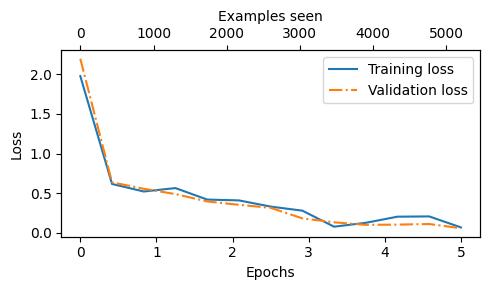

In [46]:
#그래프
import matplotlib.pyplot as plt

def plot_values(
    epochs_seen,examples_seen,train_values,val_values,label="loss"):
  fig,ax1=plt.subplots(figsize=(5,3))

  ax1.plot(epochs_seen,train_values,label=f"Training {label}")
  ax1.plot(
      epochs_seen,val_values,linestyle="-.",
      label=f"Validation {label}"
  )
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel(label.capitalize())
  ax1.legend()
  ax2=ax1.twiny()
  ax2.plot(examples_seen,train_values,alpha=0)
  ax2.set_xlabel("Examples seen")

  fig.tight_layout()
  plt.savefig(f"{label}-plot.pdf")
  plt.show()

epochs_tensor=torch.linspace(0,num_epochs,len(train_losses))
examples_seen_tensor=torch.linspace(0,examples_seen,len(train_losses))

plot_values(epochs_tensor,examples_seen_tensor,train_losses,val_losses)

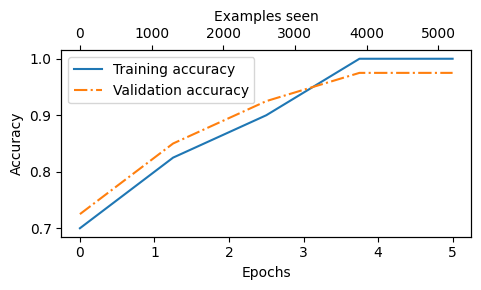

In [47]:
#분류 정확도를 그려 보자.
epochs_tensor=torch.linspace(0,num_epochs,len(train_accs))
examples_seen_tensor=torch.linspace(0,examples_seen,len(train_accs))

plot_values(
    epochs_tensor,examples_seen_tensor,train_accs,val_accs,
    label="accuracy"
)

In [51]:
#dataset에 대한 성능 계산

train_accuracy=calc_accuracy_loader(train_loader,model,device)
val_accuracy=calc_accuracy_loader(val_loader,model,device)
test_accuracy=calc_accuracy_loader(test_loader,model,device)

print(f"훈련 손실: {train_accuracy*100:.2f}%")
print(f"검증 손실: {val_accuracy*100:.2f}%")
print(f"테스트 손실: {test_accuracy*100:.2f}%")

훈련 손실: 97.60%
검증 손실: 97.32%
테스트 손실: 96.00%


#Fine-tuning된 model로 스펨 메시지 분류

In [54]:
def classify_review(
    text,model,tokenizer,device,max_length=None,
    pad_token_id=50256):
  model.eval()

  #모델을 위해 입력을 준비한다.
  input_ids=tokenizer.encode(text)
  supported_context_length=model.pos_emb.weight.shape[0]

  #시퀀스가 너무 길면 자른다.
  input_ids=input_ids[:min(max_length,supported_context_length)]

  assert max_length is not None, (
      "max_length가 지정되지 않았습니다. 모델의 최대 문맥 길이를 사용하려면"
      "max_length=model.pos_emb.weight.shape[0]로 지정하세요."
  )
  assert max_length<=supported_context_length, (
      f"max_length({max_length})가 모델이 지원하는 문맥 길이({supported_context_length})를 초과했습니다."
  )
  #가장 긴 시퀀스에 맞춰 시퀀스에 패딩을 추가한다.
  input_ids+=[pad_token_id] * (max_length - len(input_ids))
  #배치 차원을 추가한다.
  input_tensor=torch.tensor(input_ids,device=device).unsqueeze(0)

  #모델 추론을 위해 gradient 추적을 끈다.
  with torch.no_grad():
    #마지막 출력 토큰의 logits
    logits=model(input_tensor)[:,-1,:]
  predicted_label=torch.argmax(logits,dim=-1).item()

  #분류된 결과를 반환한다
  return "스팸" if predicted_label==1 else "스팸 아님"

In [55]:
text_1=(
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award"
)

print(classify_review(
    text_1, model,tokenizer,device,max_length=train_dataset.max_length
))

스팸 아님


In [56]:
text_2=(
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model,tokenizer,device,max_length=train_dataset.max_length
))

스팸 아님


In [57]:
#모델 재사용을 위해 저장
torch.save(model.state_dict(),"review_classifier.pth")